In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ev = pd.read_csv("../data/raw/ev_sessions.csv")

load = pd.read_csv(
    "../data/raw/scaled_largehotel_profile.csv"
)

load["timestamp"] = pd.to_datetime(
    load["timestamp"]
)

In [6]:
# ==========================================================
# Select the representative day
#
# From Notebook 01:
#
# Low-demand day    = Day 106 (37 kWh)
# Medium-demand day = Day 20  (303 kWh)
# High-demand day   = Day 95  (509 kWh)
#
# We start with the high-demand scenario because it
# represents the most challenging operating condition.
# ==========================================================

DAY = 95

# Extract EV sessions belonging to the selected day
ev_day = ev[ev["day"] == DAY].copy()

print("Selected day:", DAY)
print("Number of charging sessions:", len(ev_day))
print("Total EV energy demand [kWh]:",
      ev_day["energy_kwh"].sum())

Selected day: 95
Number of charging sessions: 35
Total EV energy demand [kWh]: 509.0


Building demand for day 95

In [8]:
building_day = load.iloc[
    (DAY-1)*24 : DAY*24
].copy()

building_power = (
    building_day["scaled_power_kw"]
    .to_numpy()
)

In [10]:
len(building_power)

24

In [13]:
# ==========================================================
# Build the ASAP charging profile
#
# Assumption:
# Every EV starts charging immediately after arrival
# at a fixed charger power of 7 kW.
# ==========================================================

charger_power = 7.0  # kW

hours = np.arange(24)

baseline_load = np.zeros(24)

for _, car in ev_day.iterrows():

    energy_remaining = car["energy_kwh"]

    if energy_remaining <= 0:
        continue

    start_min = int(car["connection_minute"])
    end_min = int(car["full_minute"])

    for h in range(24):

        hour_start = h * 60
        hour_end = (h + 1) * 60

        overlap_min = max(
            0,
            min(end_min, hour_end)
            - max(start_min, hour_start)
        )

        if overlap_min > 0:

            energy_this_hour = (
                charger_power
                * overlap_min / 60
            )

            energy_this_hour = min(
                energy_this_hour,
                energy_remaining
            )

            baseline_load[h] += energy_this_hour

            energy_remaining -= energy_this_hour

print("Total EV energy represented:")
print(baseline_load.sum())

Total EV energy represented:
509.0


Combining both the loads

In [14]:
total_power = (
    building_power
    + baseline_load
)

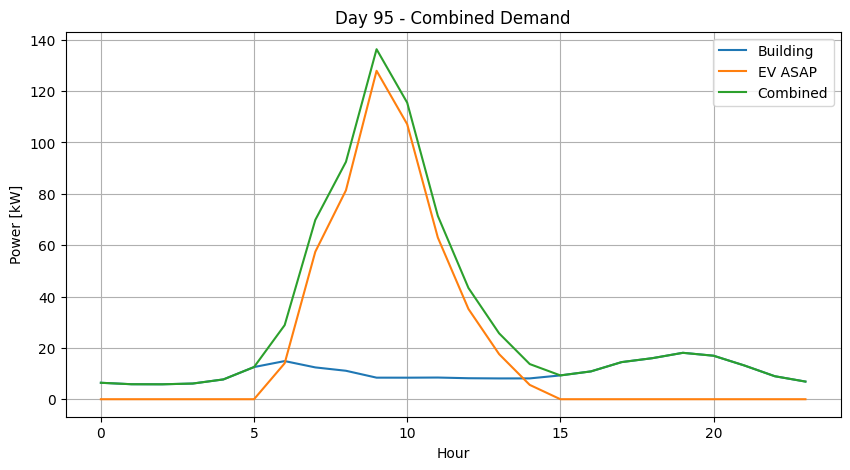

In [15]:
hours = np.arange(24)

plt.figure(figsize=(10,5))

plt.plot(
    hours,
    building_power,
    label="Building"
)

plt.plot(
    hours,
    baseline_load,
    label="EV ASAP"
)

plt.plot(
    hours,
    total_power,
    label="Combined"
)

plt.xlabel("Hour")
plt.ylabel("Power [kW]")
plt.title(
    "Day 95 - Combined Demand"
)

plt.grid()
plt.legend()
plt.show()

In [16]:
print("Building peak [kW]:", building_power.max())
print("EV peak [kW]:", baseline_load.max())
print("Combined peak [kW]:", total_power.max())

Building peak [kW]: 18.074392605274078
EV peak [kW]: 127.90000000000002
Combined peak [kW]: 136.2969846756622
